# 自定义数据集实验：表格回归（CSV）

使用仓库内 **`data/custom_housing_sample.csv`**（示例：虚构「住房面积 / 房间数 / 房龄 → 月租金」）。 你可将其 **换成自己从网上下载或整理的 CSV**：只需保证下方 **`TARGET_COLUMN`** 与特征列名一致。

**若你从网上下载数据**：放到 `data/` 下，修改 `CSV_PATH` 与 `TARGET_COLUMN`，并删除不需要的列（或在本 notebook 里 `drop`）。


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from lightgbm import LGBMRegressor

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 1. 配置数据路径与目标列


In [3]:
# 相对于「当前工作目录」的路径；建议在项目根目录启动 Jupyter：cd 到 ml-lab-classic 后执行 jupyter lab
CSV_PATH = Path("D:/Project/ml-lab-classic/ml-lab-classic/data/custom_housing_sample.csv")
TARGET_COLUMN = "monthly_rent"

df = pd.read_csv(CSV_PATH)
print("文件:", CSV_PATH.resolve())
print("形状:", df.shape)


文件: D:\Project\ml-lab-classic\ml-lab-classic\data\custom_housing_sample.csv
形状: (180, 4)


## 2. 快速查看与缺失值


In [4]:
print(df.head())
print("\n缺失值按列：\n", df.isnull().sum())

# 特征 = 除目标列外全部数值列（若有 ID/文本列请先自行删除或编码）
feature_cols = [c for c in df.columns if c != TARGET_COLUMN]
X = df[feature_cols]
y = df[TARGET_COLUMN]
print("\n特征列:", list(feature_cols))


   living_area  num_rooms  building_age  monthly_rent
0    79.176923   3.672377     23.280906    258.238386
1    55.721491   3.680340      2.993340    159.255445
2    85.101854   2.556575      2.927589    261.216249
3    73.815762   1.947787      2.192725    284.843415
4    31.592414   3.316037     16.446582    142.788561

缺失值按列：
 living_area     0
num_rooms       0
building_age    0
monthly_rent    0
dtype: int64

特征列: ['living_area', 'num_rooms', 'building_age']


## 3. 标准化与划分数据集


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)
print("训练集:", X_train.shape[0], "测试集:", X_test.shape[0])


训练集: 135 测试集: 45


## 4. 训练多个模型（SVR / KNN / LightGBM）


In [6]:
svr = SVR(kernel="rbf", C=10.0, epsilon=0.1)
svr.fit(X_train, y_train)

knn_reg = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn_reg.fit(X_train, y_train)

lgbm_reg = LGBMRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    verbose=-1,
)
lgbm_reg.fit(X_train, y_train)
print("训练完成")


训练完成


## 5. 测试集评估与可视化


SVR: MSE=398.7777, R2=0.8460
KNN: MSE=254.4031, R2=0.9018
LightGBM: MSE=223.6102, R2=0.9137


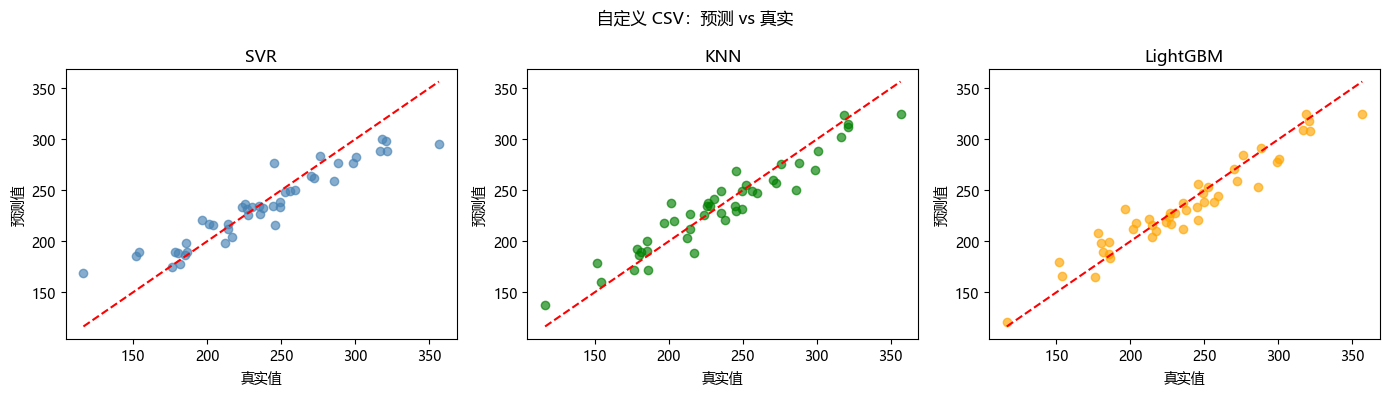

In [7]:
def evaluate(model, name):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}: MSE={mse:.4f}, R2={r2:.4f}")
    return pred

p1 = evaluate(svr, "SVR")
p2 = evaluate(knn_reg, "KNN")
p3 = evaluate(lgbm_reg, "LightGBM")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred, c in zip(
    axes,
    ["SVR", "KNN", "LightGBM"],
    [p1, p2, p3],
    ["steelblue", "green", "orange"],
):
    ax.scatter(y_test, pred, alpha=0.65, color=c)
    lo, hi = float(y_test.min()), float(y_test.max())
    ax.plot([lo, hi], [lo, hi], "r--")
    ax.set_xlabel("真实值")
    ax.set_ylabel("预测值")
    ax.set_title(f"{name}")
plt.suptitle("自定义 CSV：预测 vs 真实")
plt.tight_layout()
plt.show()
